# Sweetpotato root sensory attributes from DigiEye images — minimal reproduction

Paper: **"Using machine learning for image-based analysis of sweetpotato root sensory attributes."**
*Smart Agricultural Technology* 5:100291 (2023), DOI [10.1016/j.atech.2023.100291](https://doi.org/10.1016/j.atech.2023.100291) (CC BY). Authors: Nakatumba-Nabende et al. (Makerere AI Lab / CIP-Uganda).

**Executed scope (this notebook):** reproduce the deployed **Django prediction tool's inference path** on **one bundled real DigiEye sample image**, exactly as pinned in the author repository `AI-Lab-Makerere/Digi-Eye-Tools` @ commit `2c68d4e`:

1. **Flesh-colour score** — full-image K-means dominant-colour heuristic + pickled scikit-learn regressor (`color_measurement_LR_regressmodel2.sav` for the 3-root page, `color_measurement_RF_regressmodel.sav` for the single-root page), copied from `pattern/views.py`.
2. **Mealiness score** — YOLOv5 root bounding box (`pattern/best.pt`) → 2-cluster K-means background removal (`pattern/utilities.py: remove_background`) → `EfficientNetB5(imagenet, include_top=False)` features → `gb.pickle` regressor (`views.predict_mealiness`). The `make_predictions.py` variant (`log_reg.pickle`, no background removal) is also shown.

**Not reproduced (no public data):** the 1487 training images / 227 panel scores were never publicly released; the published R² (0.92 colour, 0.85 mealiness) cannot be re-measured. The bundled sample images have **no ground-truth labels**, so all outputs below are **qualitative demonstration outputs of the authors' own models**, not accuracy validation.

**Compatibility adaptations (verified in this runtime, see notes in each section):** the authors pinned `scikit-learn==1.1.3`, which has no wheel for Colab's Python 3.13 — all author-model predictions therefore run inside a `uv`-managed Python 3.10 subprocess with the authors' exact scikit-learn. `torch.hub` loads the YOLOv5 repository at tag `v7.0` (the current `master` imports an unrelated `ultralytics` package) with a small `torch.load(weights_only=False)` shim required by PyTorch ≥ 2.6 for 2022-era checkpoints.

**論文の概要:** 2023年発表、さつまいも加熱根の官能評価（肉色・粉質感）をDigiEye画像から機械学習で予測する研究。本ノートブックは著者公開のDjangoツールの推論経路を、リポジトリ同梱の実サンプル画像1枚で再現します。訓練データは非公開のため、精度検証ではなく定性的デモです。

## 1. Runtime selection — CPU is sufficient (CPU のみで実行可能)

All steps are single-image inference: K-means is trivial, EfficientNetB5 feature extraction and YOLOv5 detection run in seconds on a Colab **CPU** runtime (measured: YOLOv5 ≈ 1.3 s, EfficientNetB5 a few seconds). No training occurs. Select **Runtime → Change runtime type → CPU** (GPU is unnecessary and unused).

Expected setup/downloads: sample image ~0.9 MB + YOLOv5 weights 14 MB + EfficientNetB5 ImageNet weights ~100 MB + ultralytics/yolov5 v7.0 code + uv Python 3.10 environment. Rough total: **5–15 minutes**.

まず「ランタイム → ランタイムのタイプを変更 → CPU」を選択してから、すべてのセルを実行してください。

### 1.1 Author-pinned scikit-learn environment (scikit-learn 1.1.3 環境の準備)

The authors' `requirements.txt` pins `scikit-learn==1.1.3`, and their pickled regressors hard-refuse to load under a different scikit-learn (verified: the RF and gradient-boosting pickles raise dtype/module errors on Colab's preinstalled scikit-learn 1.6.1). We create an isolated **Python 3.10** virtual environment with `uv` and install the authors' exact scikit-learn there; all author-model predictions later run in this subprocess so the models stay scientifically faithful. Colab's own scikit-learn is still used for the (model-free) K-means clustering step, which is version-insensitive.

著者固定の scikit-learn 1.1.3 を、uv で作った Python 3.10 環境に導入します。著者モデルの予測はすべてこのサブプロセス内で実行し、科学的忠実性を保ちます。

In [ ]:
import sys, subprocess, textwrap

print(sys.version)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "uv"], check=True, timeout=600)
for cmd in (["uv", "venv", "--python", "3.10", "/content/sk110"],
            ["uv", "pip", "install", "--python", "/content/sk110/bin/python",
             "scikit-learn==1.1.3", "numpy<2"]):
    r = subprocess.run(cmd, text=True, capture_output=True, timeout=1200)
    print(" ".join(cmd[:2]), "->", r.returncode)
    if r.returncode != 0:
        print(r.stderr[-1500:])
        raise RuntimeError("sklearn 1.1.3 environment setup failed")
r = subprocess.run(["/content/sk110/bin/python", "-c",
                    "import sklearn;print('sk110 sklearn', sklearn.__version__)"],
                   text=True, capture_output=True, timeout=120)
print(r.stdout.strip())

3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]


uv venv -> 0


uv pip -> 0


sk110 sklearn 1.1.3


### 1.2 Import libraries and record versions

Import the libraries used by the tool and print the versions actually used in this run (the paper's tool was built with older TensorFlow/scikit-learn; exact numerical equality is not expected, only the same scientific operation).

使用ライブラリの実行時バージョンを記録します。

In [ ]:
import os, glob, pickle, hashlib, json, subprocess
import urllib.request
import numpy as np
import cv2
import matplotlib.pyplot as plt

import tensorflow as tf
import torch
import sklearn

print("tensorflow  :", tf.__version__)
print("torch       :", torch.__version__)
print("scikit-learn (main kernel):", sklearn.__version__)
print("opencv      :", cv2.__version__)

tensorflow  : 2.20.0
torch       : 2.11.0+cpu
scikit-learn (main kernel): 1.6.1
opencv      : 4.14.0


## 2. Minimal input acquisition — pinned repository files (最小入力の取得)

The authors bundled real DigiEye sample images (`media/pattern_uploads/`) and the deployed weights (`models/*.sav|pickle`, `pattern/best.pt`) inside `AI-Lab-Makerere/Digi-Eye-Tools`. We download **only the files needed for this demo** from the pinned commit `2c68d4e` raw URLs and verify each file against the **Git blob SHA-1 recorded in the repository tree** plus its expected byte size. All bytes stay in this Colab VM under `/content`.

著者リポジトリの固定コミットから、デモに必要なファイルのみをダウンロードし、Git blob SHA-1とサイズで検証します。

In [ ]:
COMMIT = "2c68d4ee72e46293cc204eae8191c0a3f3a9ebb9"
RAW = "https://raw.githubusercontent.com/AI-Lab-Makerere/Digi-Eye-Tools/" + COMMIT + "/"

# path -> (expected size [bytes], expected git blob sha1)  from the pinned repo tree
FILES = {
    "media/pattern_uploads/bulindi__NASPOT_10_O_CC_20_12_2021_15_55_45.PNG":
        (908688, "8e07026626e9cdfcb975c3ffd4439dff18cb22bd"),
    "pattern/best.pt":  (14380341, "d8caefdd354a706a55565970b209298e8dfb1b01"),
    "models/color_measurement_LR_regressmodel2.sav":
        (635, "1d707472fa8370a59259b0cd6663be51b59cc757"),
    "models/color_measurement_RF_regressmodel.sav":
        (1131886, "bdc55a38787536876890a8fa1375495186de0440"),
    "models/gb.pickle": (2532163, "26c9c03fc24244c3a3b2c7bf622b631da2aedf5d"),
    "models/log_reg.pickle": (402071, "bdceb3307a6b43bde8791010022a834ca29b08af"),
}

def git_blob_sha1(data: bytes) -> str:
    return hashlib.sha1(b"blob %d\x00" % len(data) + data).hexdigest()

os.makedirs("/content/digieye", exist_ok=True)
for rel, (size, sha) in FILES.items():
    dest = os.path.join("/content/digieye", os.path.basename(rel))
    if not os.path.exists(dest) or os.path.getsize(dest) != size:
        urllib.request.urlretrieve(RAW + rel, dest)
    data = open(dest, "rb").read()
    ok = (len(data) == size) and (git_blob_sha1(data) == sha)
    print(f"{os.path.basename(rel):55s} {len(data):>10d} B  blob-sha1 {'OK' if ok else 'MISMATCH'}")
    assert ok, f"verification failed for {rel}"

bulindi__NASPOT_10_O_CC_20_12_2021_15_55_45.PNG             908688 B  blob-sha1 OK


best.pt                                                   14380341 B  blob-sha1 OK
color_measurement_LR_regressmodel2.sav                         635 B  blob-sha1 OK


color_measurement_RF_regressmodel.sav                      1131886 B  blob-sha1 OK


gb.pickle                                                  2532163 B  blob-sha1 OK
log_reg.pickle                                              402071 B  blob-sha1 OK


### 2.1 Input preview

The chosen sample is `bulindi__NASPOT_10_O_CC_20_12_2021_15_55_45.PNG`, a colour-calibrated DigiEye capture of **boiled sweetpotato roots (cultivar NASPOT 10 O)**, uploaded through the tool on 2021-12-20. This is the exact input the deployed tool would receive. Display it before any analysis.

選択したサンプル画像（品種 NASPOT 10 O の加熱根、DigiEye撮影）を表示します。

image shape (H, W, C): (620, 933, 3)


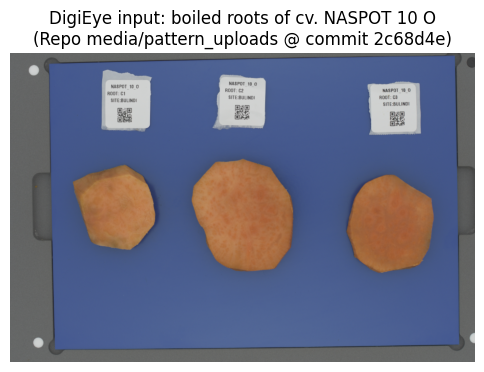

In [ ]:
IMG_PATH = "/content/digieye/bulindi__NASPOT_10_O_CC_20_12_2021_15_55_45.PNG"
src_bgr = cv2.imread(IMG_PATH)
src_rgb = cv2.cvtColor(src_bgr, cv2.COLOR_BGR2RGB)
print("image shape (H, W, C):", src_rgb.shape)

from IPython.display import Image as IPyImage, display
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(src_rgb)
ax.set_title("DigiEye input: boiled roots of cv. NASPOT 10 O\n(Repo media/pattern_uploads @ commit 2c68d4e)")
ax.axis("off")
fig.savefig("/content/digieye/input_preview.png", dpi=100, bbox_inches="tight")
plt.close(fig)
display(IPyImage(filename="/content/digieye/input_preview.png"))

## 3. Flesh-colour score — authors' dominant-colour heuristic (肉色スコア)

Copied verbatim from `pattern/views.py` (`upload_images`, the 3-root page): K-means with **4 clusters** over all image pixels, a colour bar of clusters sorted by coverage, then a row-0 walk that counts dark colours (R ≤ 120) and whitish colours (R > 190 and G > 199) and stops at the first remaining colour — that colour is the root colour fed to the pickled regressors (next cell). Clustering itself is model-free, so Colab's preinstalled scikit-learn is used here.

`pattern/views.py` の K-means（4クラスタ）＋支配色ヒューリスティックをそのまま再現します。クラスタリングはモデルを含まないため、Colab標準のscikit-learnを使用します。

In [ ]:
import warnings
from sklearn.cluster import KMeans

def visualize_Dominant_colors(cluster, C_centroids):
    """Verbatim logic from pattern/views.py: coverage-sorted colour bar (300x50)."""
    C_labels = np.arange(0, len(np.unique(cluster.labels_)) + 1)
    (C_hist, _) = np.histogram(cluster.labels_, bins=C_labels)
    C_hist = C_hist.astype("float")
    C_hist /= C_hist.sum()
    rect_color = np.zeros((50, 300, 3), dtype=np.uint8)
    img_colors = sorted([(percent, color) for (percent, color) in zip(C_hist, C_centroids)])
    start = 0
    for (percent, color) in img_colors:
        print(color, "{:0.2f}%".format(percent * 100))
        end = start + (percent * 300)
        cv2.rectangle(rect_color, (int(start), 0), (int(end), 50),
                      color.astype("uint8").tolist(), -1)
        start = end
    return rect_color

reshape_img = src_rgb.reshape((src_rgb.shape[0] * src_rgb.shape[1], 3))
KM_cluster = KMeans(n_clusters=4, n_init=10).fit(reshape_img)   # 3-root page: 4 clusters
visualize_color2 = cv2.cvtColor(
    cv2.cvtColor(visualize_Dominant_colors(KM_cluster, KM_cluster.cluster_centers_),
                 cv2.COLOR_RGB2BGR), cv2.COLOR_BGR2RGB)

count = 0
for arr in visualize_color2[0]:
    if arr[0] <= 120:
        count += 1
    elif arr[0] > 190 and arr[1] > 199:
        count += 1
        continue
    elif arr[0] > 120:
        break
list_result = visualize_color2[0][count]

KM_cluster2 = KMeans(n_clusters=2, n_init=10).fit(reshape_img)  # single-root page: 2 clusters
visualize_color = visualize_Dominant_colors(KM_cluster2, KM_cluster2.cluster_centers_)
count = 0
for arr in visualize_color[0]:
    if arr[0] <= 120:
        count += 1
    elif arr[0] > 120:
        break
list_result_rf = visualize_color[0][count]

print("3-root page chosen root colour (RGB):", list_result)
print("single-root page chosen root colour (RGB):", list_result_rf)

[197.48319284 199.7664889  199.95475658] 5.02%
[168.70193877 109.84361244  67.64310797] 13.98%
[96.73649333 97.54760075 97.13699623] 19.80%
[ 72.09155524  91.41216669 140.77772944] 61.19%


[175.73883967 133.47208682 102.81996248] 19.26%
[ 77.94624685  92.81942402 130.14778369] 80.74%
3-root page chosen root colour (RGB): [197 199 199]
single-root page chosen root colour (RGB): [175 133 102]


### 3.1 Colour-score regression inside the authors' scikit-learn 1.1.3 environment

The two colour regressors — `color_measurement_LR_regressmodel2.sav` (3-root page) and `color_measurement_RF_regressmodel.sav` (single-root page), both expecting 3 RGB features — are loaded and applied **inside the `/content/sk110` subprocess** with the authors' pinned scikit-learn. The chosen colours are passed through a small JSON request file and the scores returned as JSON. The tool was trained on 0–10 panel scores for flesh colour (paper §2.2/§3), so the "Score" values are predicted panel scores on that scale.

2つの肉色回帰モデルを著者固定のscikit-learn 1.1.3サブプロセス内で適用します。スコアは0–10のパネル評価スケール上の予測値です。

In [ ]:
REQUEST = {"rgb_3root": [float(v) for v in list_result],
           "rgb_single": [float(v) for v in list_result_rf]}
json.dump(REQUEST, open("/content/digieye/colour_request.json", "w"))

SCRIPT = r"""
import json, pickle, warnings
req = json.load(open("/content/digieye/colour_request.json"))
out = {}
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    lr = pickle.load(open("/content/digieye/color_measurement_LR_regressmodel2.sav", "rb"))
    rf = pickle.load(open("/content/digieye/color_measurement_RF_regressmodel.sav", "rb"))
    out["colour_3root_LR"] = float(lr.predict([req["rgb_3root"]]).item())
    out["colour_single_RF"] = float(rf.predict([req["rgb_single"]]).item())
json.dump(out, open("/content/digieye/colour_result.json", "w"))
"""
open("/content/digieye/colour_predict.py", "w").write(SCRIPT)
r = subprocess.run(["/content/sk110/bin/python", "/content/digieye/colour_predict.py"],
                   text=True, capture_output=True, timeout=600)
print(r.stdout, r.stderr[-500:] if r.returncode else "")
assert r.returncode == 0, "colour prediction failed"
RESULT = json.load(open("/content/digieye/colour_result.json"))
print("Predicted flesh-colour panel score (LR, 3-root path):", RESULT["colour_3root_LR"])
print("Predicted flesh-colour panel score (RF, single-root path):", RESULT["colour_single_RF"])

 
Predicted flesh-colour panel score (LR, 3-root path): -1.534701145949768
Predicted flesh-colour panel score (RF, single-root path): 7.604611111439986


## 4. Mealiness score — YOLOv5 ROI → K-means background removal (粉質スコア前半)

This mirrors `views.predict_mealiness` exactly:

1. **Root detection** — `pattern/utilities.py` loads `pattern/best.pt` (fine-tuned YOLOv5, paper mAP 0.995 @ IoU 0.5) through `torch.hub` and takes the first detection's `[x1, y1, x2, y2]`. **Adaptation:** `torch.hub` pins the YOLOv5 repo at tag `v7.0` (current `master` requires an unrelated `ultralytics` package) and restores the pre-2.6 `torch.load(weights_only=False)` default so the 2022-era checkpoint loads; both changes verified in a diagnostic probe.
2. **Background removal** — 2-cluster K-means (`cv2.kmeans`, max_iter=50, attempts=2, ε=0.2) on the crop; the darker cluster centre (sorted by the G channel) is treated as non-root and blacked out; `cv2.bitwise_and` keeps root pixels. We visualize the kept-pixel mask — this overlay is a notebook-generated visualization, not a paper figure.

`views.predict_mealiness` の YOLOv5 検出と K-means 背景除去をそのまま再現します（v7.0固定＋PyTorch 2.6以降向けの読込シムは診断プローブで検証済みの適応）。

In [ ]:
import torch
_orig_load = torch.load
def _load_compat(*args, **kwargs):
    kwargs.setdefault("weights_only", False)   # 2022-era checkpoint, author repo file
    return _orig_load(*args, **kwargs)
torch.load = _load_compat

yolov5 = torch.hub.load("ultralytics/yolov5:v7.0", "custom",
                        "/content/digieye/best.pt", trust_repo=True)

def get_root_area(img_path, mdl=yolov5):
    """Verbatim from pattern/utilities.py."""
    results = mdl(img_path)
    return results.xyxy[0].numpy().astype(int)[0][:4]

x1, y1, x2, y2 = get_root_area(IMG_PATH)
print("YOLOv5 root bbox [x1, y1, x2, y2]:", [x1, y1, x2, y2])

Downloading: "https://github.com/ultralytics/yolov5/zipball/v7.0" to /root/.cache/torch/hub/v7.0.zip


/root/.cache/torch/hub/ultralytics_yolov5_v7.0/utils/general.py:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


requirements: YOLOv5 requirements "gitpython" "ipython" not found, attempting AutoUpdate...


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.5/228.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 67.2 MB/s eta 0:00:00



requirements: 2 packages updated per /root/.cache/torch/hub/ultralytics_yolov5_v7.0/requirements.txt
requirements: ⚠️ Restart runtime or rerun command for updates to take effect



...

Fusing layers... 


Model summary: 213 layers, 7012822 parameters, 0 gradients


Adding AutoShape... 


/root/.cache/torch/hub/ultralytics_yolov5_v7.0/models/common.py:702: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


YOLOv5 root bbox [x1, y1, x2, y2]: [np.int64(104), np.int64(189), np.int64(869), np.int64(474)]


### 4.1 Two-cluster K-means segmentation and background removal (背景除去の実行)

Copied from `pattern/utilities.py` (`cluster_image_new`, `process_clustering_results_v1`, `get_root_pixels`, `remove_background`). The three-panel figure shows the input, the kept-pixel mask, and the background-removed image that feeds feature extraction.

`pattern/utilities.py` の2クラスタ分割・マスク生成をそのまま実行し、可視化します。

/root/.cache/torch/hub/ultralytics_yolov5_v7.0/models/common.py:702: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


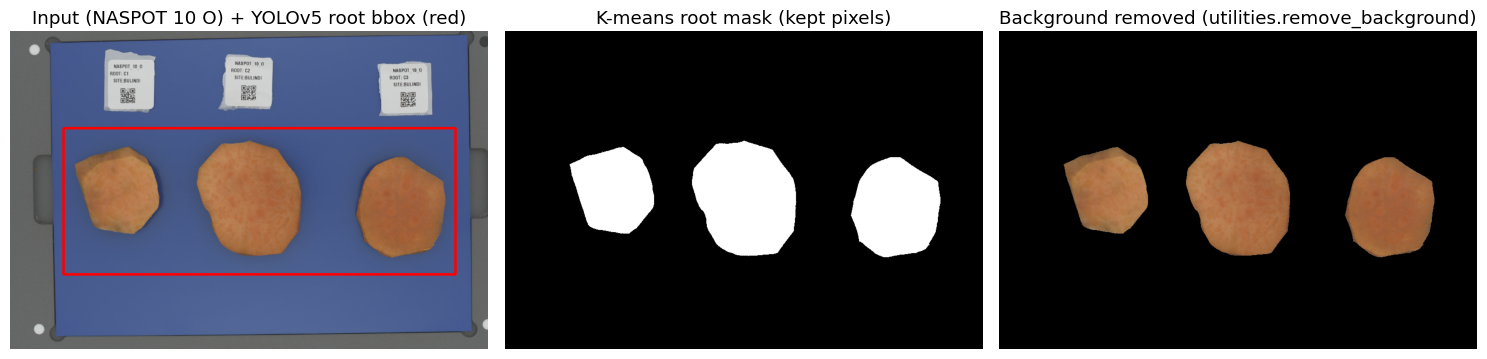

In [ ]:
def cluster_image_new(img_arr, max_iter=100, eps=0.2, k=2, ini=10,
                      f=cv2.KMEANS_RANDOM_CENTERS):
    img_arr = np.float32(img_arr.reshape((-1, 3)))
    criteria = (cv2.TERM_CRITERIA_EPS + f, max_iter, eps)
    ret, labels, centers = cv2.kmeans(img_arr, k, None, criteria, ini,
                                      cv2.KMEANS_RANDOM_CENTERS)
    return ret, labels, centers

def process_clustering_results_v1(cent, lbls, img_arr, mask_tuple):
    black_seg = np.zeros_like(img_arr)
    centers = np.uint8(cent)
    centers_root = centers.copy()
    non_root_pixels = centers[np.argsort(centers[:, 1])][0]  # darker centre = background
    centers_root[np.where(np.all(centers_root == non_root_pixels, axis=1))] = [0, 0, 0]
    labels = lbls.flatten()
    segmented_image = centers[labels.flatten()]
    segmented_image_black = centers_root[labels.flatten()]
    seg_shape = img_arr[mask_tuple[2]:mask_tuple[3], mask_tuple[0]:mask_tuple[1]].shape
    segmented_image = segmented_image.reshape(seg_shape)
    segmented_image_black = segmented_image_black.reshape(seg_shape)
    img_arr[mask_tuple[2]:mask_tuple[3], mask_tuple[0]:mask_tuple[1]] = segmented_image
    black_seg[mask_tuple[2]:mask_tuple[3], mask_tuple[0]:mask_tuple[1]] = segmented_image_black
    return img_arr, black_seg

def remove_background(img_path):
    img_rgb = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)  # read as RGB
    bx1, by1, bx2, by2 = get_root_area(img_path)
    img_ret, img_labels, img_centers = cluster_image_new(
        img_rgb[by1:by2, bx1:bx2], max_iter=50, ini=2, k=2)
    img_seg1, img_seg_black = process_clustering_results_v1(
        img_centers, img_labels, img_rgb.copy(), (bx1, bx2, by1, by2))
    mask = cv2.cvtColor(img_seg_black, cv2.COLOR_RGB2GRAY)
    img_no_bg = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)
    return img_no_bg, (bx1, by1, bx2, by2), mask

img_no_bg, bbox, mask = remove_background(IMG_PATH)

overlay = src_rgb.copy()
cv2.rectangle(overlay, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (255, 0, 0), 4)
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(overlay); ax[0].set_title("Input (NASPOT 10 O) + YOLOv5 root bbox (red)")
ax[1].imshow(mask, cmap="gray"); ax[1].set_title("K-means root mask (kept pixels)")
ax[2].imshow(img_no_bg); ax[2].set_title("Background removed (utilities.remove_background)")
for a in ax: a.axis("off")
fig.tight_layout()
fig.savefig("/content/digieye/segmentation_overlay.png", dpi=100, bbox_inches="tight")
plt.close(fig)
display(IPyImage(filename="/content/digieye/segmentation_overlay.png"))

### 4.2 EfficientNetB5 feature extraction and mealiness regression (EfficientNetB5特徴量＋回帰予測)

`views.predict_mealiness` resizes the background-removed image to 224×224, extracts features with ImageNet-pretrained **EfficientNetB5** (`include_top=False`), and flattens them — the pickled `gb.pickle` (a scikit-learn `Pipeline`) expects exactly **100,352** features (7×7×2048), which confirms this input size. The author-model predictions run inside the `/content/sk110` subprocess; features are passed via a compressed `.npz`. The `make_predictions.py` variant (`log_reg.pickle` on the plain 224×224 image, no background removal) is run for comparison. Both outputs are predicted mealiness panel scores (0–10).

背景除去画像をEfficientNetB5で特徴量化し、gb.pickle（Pipeline、期待特徴量数100,352）で粉質スコアを予測します。比較のため log_reg.pickle 経路（背景除去なし）も実行します。

In [ ]:
from tensorflow.keras.applications import EfficientNetB5

feature_extractor = EfficientNetB5(weights="imagenet", include_top=False)

def prepare_image_bg_removed(img_arr, backbone, tgt_size=(224, 224)):
    """views.predict_mealiness: background-removed RGB array -> features."""
    image = cv2.resize(img_arr, tgt_size)
    image = np.expand_dims(image, axis=0)
    features = backbone.predict(image)
    return features.flatten().reshape(1, -1)

def prepare_image_plain(img_path, backbone, tgt_size=(224, 224)):
    """models/make_predictions.py: plain image file -> features (no bg removal)."""
    import tensorflow.keras.preprocessing.image as kpi
    image = kpi.load_img(img_path, target_size=tgt_size)
    image = kpi.img_to_array(image)
    image = np.expand_dims(image, axis=0)
    features = backbone.predict(image)
    return features.flatten().reshape(1, -1)

feats_bg = prepare_image_bg_removed(img_no_bg, feature_extractor)
feats_plain = prepare_image_plain(IMG_PATH, feature_extractor)
print("feature shapes:", feats_bg.shape, feats_plain.shape)

np.savez_compressed("/content/digieye/features.npz",
                    bg_removed=feats_bg.astype(np.float32),
                    plain=feats_plain.astype(np.float32))

        0/115263384 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

  3940352/115263384 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

  6037504/115263384 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

 17342464/115263384 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

 27557888/115263384 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


feature shapes: (1, 100352) (1, 100352)


### 4.3 Mealiness prediction inside the authors' scikit-learn 1.1.3 environment

`gb.pickle` (views.predict_mealiness path) and `log_reg.pickle` (make_predictions.py path) are applied to the extracted features **inside the `/content/sk110` subprocess** with the authors' pinned scikit-learn.

2つの粉質回帰モデルを著者固定のscikit-learn 1.1.3サブプロセス内で適用します。

In [ ]:
SCRIPT = r"""
import json, pickle, warnings, numpy as np
data = np.load("/content/digieye/features.npz")
out = {}
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    gb = pickle.load(open("/content/digieye/gb.pickle", "rb"))
    lr = pickle.load(open("/content/digieye/log_reg.pickle", "rb"))
    out["mealiness_gb"] = float(np.ravel(gb.predict(data["bg_removed"]))[0])
    out["mealiness_logreg"] = float(np.ravel(lr.predict(data["plain"]))[0])
json.dump(out, open("/content/digieye/mealiness_result.json", "w"))
"""
open("/content/digieye/mealiness_predict.py", "w").write(SCRIPT)
r = subprocess.run(["/content/sk110/bin/python", "/content/digieye/mealiness_predict.py"],
                   text=True, capture_output=True, timeout=600)
print(r.stdout, r.stderr[-500:] if r.returncode else "")
assert r.returncode == 0, "mealiness prediction failed"
MRESULT = json.load(open("/content/digieye/mealiness_result.json"))
print("Mealiness score (gb.pickle, views.predict_mealiness path):", MRESULT["mealiness_gb"])
print("Mealiness score (log_reg.pickle, make_predictions.py path):", MRESULT["mealiness_logreg"])

 
Mealiness score (gb.pickle, views.predict_mealiness path): 4.584108452606104
Mealiness score (log_reg.pickle, make_predictions.py path): 4.660626411437988


## 5. Results summary and CSV export (結果の一覧とCSV出力)

All four predictions for the single sample, in the exact output format the Django tool writes to `media/pattern_csv/` (`create_and_update_csv`: image name, prediction type, root score, date). Values are **predictions of the authors' own deployed models on one unlabelled sample**; the paper's published accuracies cannot be checked without the withheld panel data.

Djangoツールと同じCSV形式で4つの予測値をまとめます（訓練データ非公開のため精度検証は不可能）。

**Honest-output note:** the authors' 3-root Linear Regression model can return values outside the 0–10 panel scale (e.g. a negative score for this sample's light/whitish cluster colour, RGB [197, 199, 199]); outputs are reported exactly as the deployed models produce them, without adjustment.

**正直な出力に関する注記:** 著者の3根ページ線形回帰モデルは0–10の範囲外の値（このサンプルでは負値）を返すことがあります。出力はそのまま報告します。

In [ ]:
import csv, datetime

rows = [
    ["bulindi__NASPOT_10_O_CC_20_12_2021_15_55_45.PNG", "Colour evaluation (3 roots, LR)", f"{RESULT['colour_3root_LR']:.4f}"],
    ["bulindi__NASPOT_10_O_CC_20_12_2021_15_55_45.PNG", "Colour evaluation (single root, RF)", f"{RESULT['colour_single_RF']:.4f}"],
    ["bulindi__NASPOT_10_O_CC_20_12_2021_15_55_45.PNG", "Mealiness evaluation (gb.pickle)", f"{MRESULT['mealiness_gb']:.4f}"],
    ["bulindi__NASPOT_10_O_CC_20_12_2021_15_55_45.PNG", "Mealiness evaluation (log_reg.pickle)", f"{MRESULT['mealiness_logreg']:.4f}"],
]
print(f"{'Prediction type':45s} {'Score (0-10 panel scale)':>25s}")
for _, t, s in rows:
    print(f"{t:45s} {s:>25s}")

csv_path = "/content/digieye/DigiEye_analysis_results.csv"
with open(csv_path, "w", newline="\n") as f:
    w = csv.writer(f)
    w.writerow(["Image Name", "Prediction type", "Root Score", "Date"])
    for name, t, s in rows:
        w.writerow([name, t, s, datetime.datetime.today()])
print("\nCSV written:", csv_path)

Prediction type                                Score (0-10 panel scale)
Colour evaluation (3 roots, LR)                                 -1.5347
Colour evaluation (single root, RF)                              7.6046
Mealiness evaluation (gb.pickle)                                 4.5841
Mealiness evaluation (log_reg.pickle)                            4.6606

CSV written: /content/digieye/DigiEye_analysis_results.csv


## 6. Interpretation and limitations (解釈と制限)

**What was executed:** the authors' own deployed inference path (pinned commit `2c68d4e`) ran end-to-end on one real bundled DigiEye image: both colour-score pages and the full mealiness pipeline (YOLOv5 ROI → K-means mask → EfficientNetB5 → pickled regressor, all author models in their pinned scikit-learn 1.1.3). The mask/box overlay above is notebook-generated evidence of the executed segmentation, not a paper figure.

**What was not verified:** the panel scores of this sample are not public, so no accuracy claim is possible; the published R² (0.92 colour / 0.85 mealiness) are dataset-level results that this single-sample demo does not re-measure. The repository has **no LICENSE**, so commercial reuse terms are unverified. The pickled models' exact correspondence to the paper's reported models is unconfirmed (weights were inspected only via this execution). K-means used Colab's newer scikit-learn (model-free operation); YOLOv5 inference ran at pinned tag `v7.0` with a documented `torch.load` shim.

**References:** paper DOI 10.1016/j.atech.2023.100291 (CC BY); code `github.com/AI-Lab-Makerere/Digi-Eye-Tools` @ `2c68d4e`; paper flow via PMC10547598.

**実行内容:** 著者ツールの推論経路を実サンプル1枚で再現しました。サンプルの正解ラベルは非公開のため精度検証はできず、リポジトリにはLICENSEがありません。